#Выполнил

Неустроев Сергей, 409232

In [24]:
# @title Импорт библиотек

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import os

In [25]:
# @title Загрузка данных с Google Drive
print("Загрузка датасетов")
# Автоматическая конвертация ссылок для прямого скачивания через gdown
file_ids = {
    'd1.csv': '16VzwtrZRP9QScMdueb3BK0fvZtP8a6sH',
    'd2.csv': '13npPTtGGiKyug7fEKyvaZZbFavFkhGLm'
}

for filename, file_id in file_ids.items():
    if not os.path.exists(filename):
        url = f'https://drive.google.com/uc?id={file_id}'
        os.system(f'gdown --id {file_id} -O {filename}')
    else:
        continue

Загрузка датасетов


In [26]:
#@title Реализация основных компонентов нейросети

class DenseLayer:
    def __init__(self, input_dim, output_dim):
        # Инициализация для предотвращения затухания градиентов
        self.weights = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / input_dim)
        self.biases = np.zeros((1, output_dim))

        # Переменные для оптимизаторов
        self.v_w = np.zeros_like(self.weights)  # Для Momentum / Adam
        self.v_b = np.zeros_like(self.biases)
        self.m_w = np.zeros_like(self.weights)  # Для Adam (первый момент)
        self.m_b = np.zeros_like(self.biases)

    def forward(self, inputs):
        self.inputs = inputs
        return np.dot(inputs, self.weights) + self.biases

    def backward(self, output_gradient):
        # Градиенты по параметрам слоя
        self.d_weights = np.dot(self.inputs.T, output_gradient)
        self.d_biases = np.sum(output_gradient, axis=0, keepdims=True)
        # Градиент по входу (передается на предыдущий слой)
        return np.dot(output_gradient, self.weights.T)

class ReLU:
    def forward(self, inputs):
        self.inputs = inputs
        return np.maximum(0, inputs)

    def backward(self, output_gradient):
        return output_gradient * (self.inputs > 0).astype(float)

class SoftmaxCrossEntropy:
    def forward(self, logits, y_true):
        self.y_true = y_true
        # Стабильный Softmax
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        self.probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

        # Расчет Cross-Entropy Loss
        n_samples = logits.shape[0]
        loss = -np.sum(y_true * np.log(self.probs + 1e-15)) / n_samples
        return loss, self.probs

    def backward(self):
        n_samples = self.y_true.shape[0]
        # Градиент функции потерь по логитам (входам софтмакса)
        return (self.probs - self.y_true) / n_samples

In [27]:
# @title Алгоритмы оптимизации

class SGDMomentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum

    def update(self, layer):
        layer.v_w = self.momentum * layer.v_w + self.lr * layer.d_weights
        layer.v_b = self.momentum * layer.v_b + self.lr * layer.d_biases
        layer.weights -= layer.v_w
        layer.biases -= layer.v_b

class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0

    def update(self, layer):
        if self.t == 0:
            self.t = 1

        # Обновление скользящего среднего градиентов (1-й момент)
        layer.m_w = self.beta1 * layer.m_w + (1 - self.beta1) * layer.d_weights
        layer.m_b = self.beta1 * layer.m_b + (1 - self.beta1) * layer.d_biases

        # Обновление скользящего среднего квадратов градиентов (2-й момент)
        layer.v_w = self.beta2 * layer.v_w + (1 - self.beta2) * (layer.d_weights ** 2)
        layer.v_b = self.beta2 * layer.v_b + (1 - self.beta2) * (layer.d_biases ** 2)

        # Корректировка смещения
        m_w_corrected = layer.m_w / (1 - self.beta1 ** self.t)
        m_b_corrected = layer.m_b / (1 - self.beta1 ** self.t)
        v_w_corrected = layer.v_w / (1 - self.beta2 ** self.t)
        v_b_corrected = layer.v_b / (1 - self.beta2 ** self.t)

        # Обновление весов
        layer.weights -= self.lr * m_w_corrected / (np.sqrt(v_w_corrected) + self.epsilon)
        layer.biases -= self.lr * m_b_corrected / (np.sqrt(v_b_corrected) + self.epsilon)

In [28]:
# @title Каркас нейронной сети

class NeuralNetwork:
    def __init__(self, input_dim, hidden_dim, output_dim, optimizer):
        self.layer1 = DenseLayer(input_dim, hidden_dim)
        self.activation1 = ReLU()
        self.layer2 = DenseLayer(hidden_dim, output_dim)
        self.loss_layer = SoftmaxCrossEntropy()
        self.optimizer = optimizer

    def forward(self, X, y_one_hot):
        out = self.layer1.forward(X)
        out = self.activation1.forward(out)
        logits = self.layer2.forward(out)
        loss, probs = self.loss_layer.forward(logits, y_one_hot)
        return loss, probs

    def backward(self):
        grad = self.loss_layer.backward()
        grad = self.layer2.backward(grad)
        grad = self.activation1.backward(grad)
        self.layer1.backward(grad)

    def update_weights(self):
        if isinstance(self.optimizer, Adam):
            self.optimizer.t += 1
        self.optimizer.update(self.layer1)
        self.optimizer.update(self.layer2)

    def fit(self, X_train, y_train, X_val, y_val, epochs=150, batch_size=32):
        train_losses = []
        val_losses = []

        num_classes = len(np.unique(y_train))
        y_train_oh = np.eye(num_classes)[y_train]
        y_val_oh = np.eye(num_classes)[y_val]

        for epoch in range(epochs):
            # Перемешивание батчей
            permutation = np.random.permutation(X_train.shape[0])
            X_train_shuffled = X_train[permutation]
            y_train_shuffled = y_train_oh[permutation]

            epoch_losses = []
            for i in range(0, X_train.shape[0], batch_size):
                X_batch = X_train_shuffled[i:i+batch_size]
                y_batch = y_train_shuffled[i:i+batch_size]

                loss, _ = self.forward(X_batch, y_batch)
                self.backward()
                self.update_weights()
                epoch_losses.append(loss)

            train_losses.append(np.mean(epoch_losses))
            val_loss, _ = self.forward(X_val, y_val_oh)
            val_losses.append(val_loss)

        return train_losses, val_losses

    def predict(self, X):
        # Передаем нулевой dummy-вектор для y_true, так как нам нужны только вероятности
        dummy_y = np.zeros((X.shape[0], self.layer2.weights.shape[1]))
        _, probs = self.forward(X, dummy_y)
        return np.argmax(probs, axis=1)

 Обработка Датасет d1
Результаты для Датасет d1:
  F1-Score (SGD с Momentum): 1.0000
  F1-Score (Adam):           1.0000


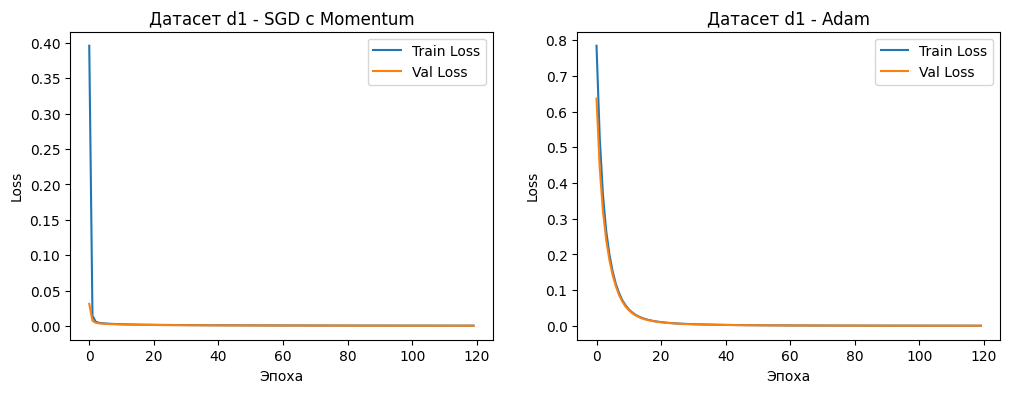

 Обработка Датасет d2
Результаты для Датасет d2:
  F1-Score (SGD с Momentum): 1.0000
  F1-Score (Adam):           1.0000


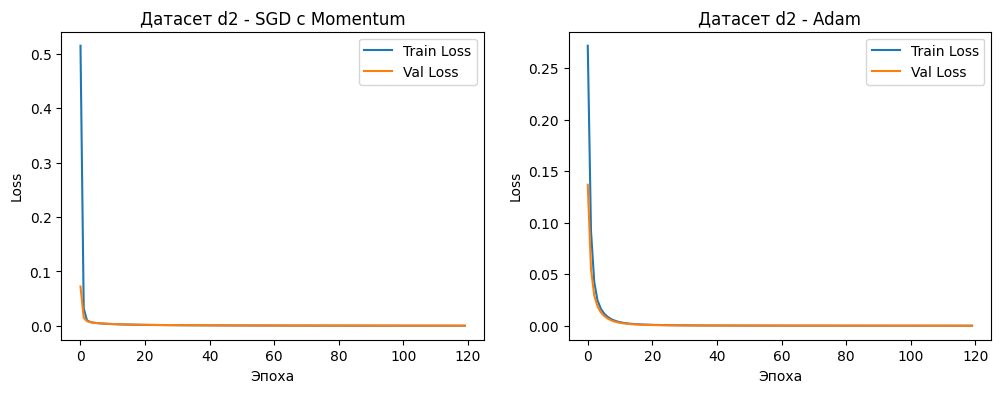

Текущая промежуточная сумма взвешенных F1 (0.3*d1 + 0.3*d2): 0.6000


In [29]:
# @title Пайплан обучения и валидации

def process_dataset(filepath, name):
    print(f" Обработка {name}")
    df = pd.read_csv(filepath)

    # Предполагается, что целевая переменная находится в последнем столбце
    X = df.iloc[:, :-1].values
    y = df.iloc[:, -1].values

    # Кодирование меток классов в диапазон [0, C-1], если они не закодированы
    unique_labels = np.unique(y)
    label_map = {label: idx for idx, label in enumerate(unique_labels)}
    y = np.array([label_map[label] for label in y])

    # Разбиение данных в отношении 80/20
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Масштабирование признаков
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    input_dim = X_train.shape[1]
    output_dim = len(unique_labels)

    # Настройки экспериментов
    epochs = 120
    hidden_dim = 16

    # Тест 1: SGD с Momentum
    nn_sgd = NeuralNetwork(input_dim, hidden_dim, output_dim, SGDMomentum(lr=0.01))
    sgd_train_loss, sgd_val_loss = nn_sgd.fit(X_train, y_train, X_val, y_val, epochs=epochs)
    sgd_preds = nn_sgd.predict(X_val)
    sgd_f1 = f1_score(y_val, sgd_preds, average='macro')

    # Тест 2: Adam
    nn_adam = NeuralNetwork(input_dim, hidden_dim, output_dim, Adam(lr=0.003))
    adam_train_loss, adam_val_loss = nn_adam.fit(X_train, y_train, X_val, y_val, epochs=epochs)
    adam_preds = nn_adam.predict(X_val)
    adam_f1 = f1_score(y_val, adam_preds, average='macro')

    print(f"Результаты для {name}:")
    print(f"  F1-Score (SGD с Momentum): {sgd_f1:.4f}")
    print(f"  F1-Score (Adam):           {adam_f1:.4f}")

    # Визуализация сходимости
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(sgd_train_loss, label='Train Loss')
    plt.plot(sgd_val_loss, label='Val Loss')
    plt.title(f'{name} - SGD с Momentum')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(adam_train_loss, label='Train Loss')
    plt.plot(adam_val_loss, label='Val Loss')
    plt.title(f'{name} - Adam')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    return max(sgd_f1, adam_f1)

# Запуск пайплайна для d1 и d2
f1_d1 = process_dataset('d1.csv', 'Датасет d1')
f1_d2 = process_dataset('d2.csv', 'Датасет d2')

# Проверка пограничного критерия
expected_score_min = 0.3 * f1_d1 + 0.3 * f1_d2
print(f"Текущая промежуточная сумма взвешенных F1 (0.3*d1 + 0.3*d2): {expected_score_min:.4f}")